## Exploratory Data Analysis voor klachten train set
### Notebook EDA klachten classificatie voor correcte expertise

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np
from sklearn.model_selection import train_test_split

In [21]:
df = pd.read_csv("klacht_train.csv")

In [22]:
df.head()

,ID,Datum_ontvangst,Product,Omschrijving,Antwoord_bedrijf,Omschrijving_lengte,Antwoord_lengte
0,1753142,2024-01-21,Hypotheek,My financial hardship began when my husband wh...,Closed with explanation,1837,23
1,1304291,2023-03-27,Hypotheek,On or about XXXX XXXX I applied for a modifica...,Closed with explanation,2627,23
2,1532095,2023-08-23,Bankrekening,I have XXXX bad things on Regions bank that ju...,Closed with explanation,397,23
3,1479068,2023-07-21,Incasso,This was a payday loan from XXXX and the callI...,Untimely response,144,17
4,2367063,2025-03-01,Incasso,I got an alert today that the company SENTRY C...,Closed with explanation,512,23


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11909 entries, 0 to 11908
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   11909 non-null  int64 
 1   Datum_ontvangst      11909 non-null  object
 2   Product              11909 non-null  object
 3   Omschrijving         11909 non-null  object
 4   Antwoord_bedrijf     11909 non-null  object
 5   Omschrijving_lengte  11909 non-null  int64 
 6   Antwoord_lengte      11909 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 651.4+ KB


In [24]:
df.describe()

,ID,Omschrijving_lengte,Antwoord_lengte
count,1.190900e+04,11909.000000,11909.000000
mean,1.904232e+06,1025.506592,23.799227
std,3.406448e+05,916.164458,3.916677
min,1.290157e+06,12.000000,6.000000
25%,1.602650e+06,379.000000,23.000000
50%,1.926095e+06,713.000000,23.000000
75%,2.206534e+06,1371.000000,23.000000
max,2.543247e+06,10761.000000,31.000000


In [25]:
df['Product'].unique()

array(['Hypotheek', 'Bankrekening', 'Incasso', 'Kredietregistratie',
       'Creditcard', 'Consumentenkrediet'], dtype=object)

In [26]:
df['Antwoord_bedrijf'].unique()

array(['Closed with explanation', 'Untimely response',
       'Closed with non-monetary relief', 'Closed with monetary relief',
       'Closed'], dtype=object)

In [27]:
df['Datum_ontvangst'].agg(['min', 'max'])

min    2023-03-19
max    2025-04-30
Name: Datum_ontvangst, dtype: object

#### Visualisaties

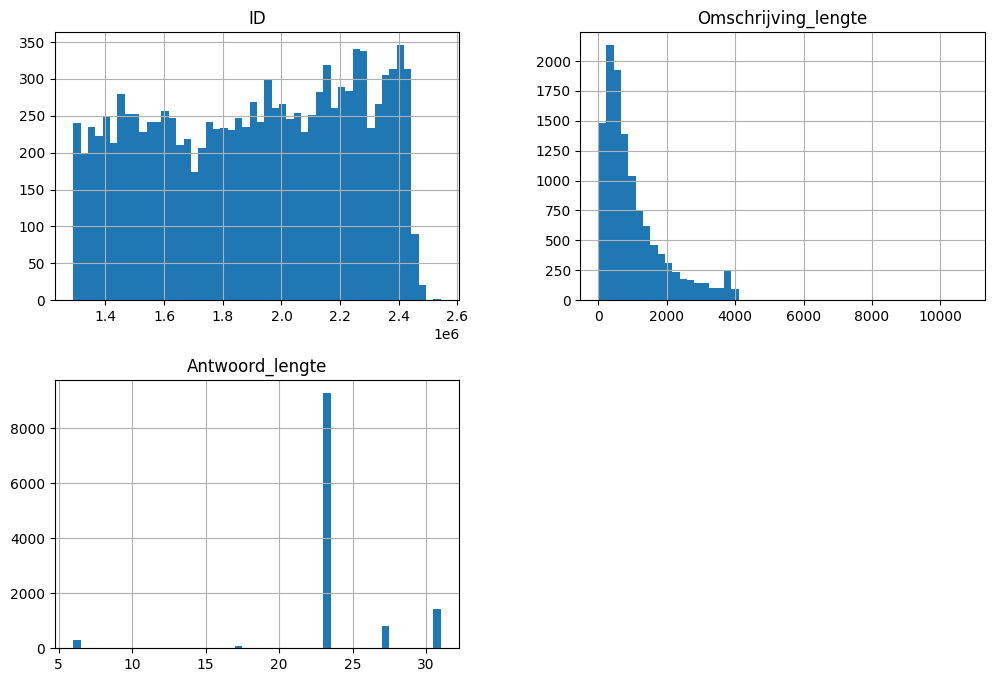

In [28]:
df.hist(bins=50, figsize=(12, 8))
plt.show()

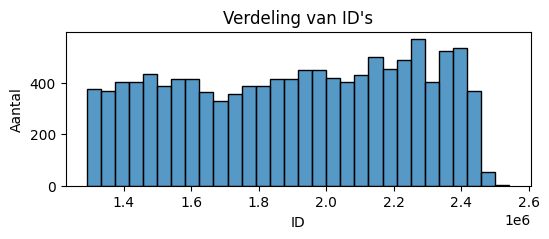

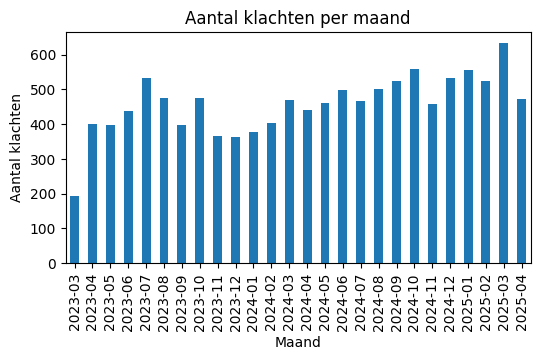

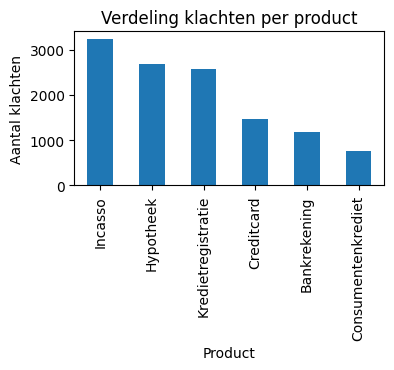

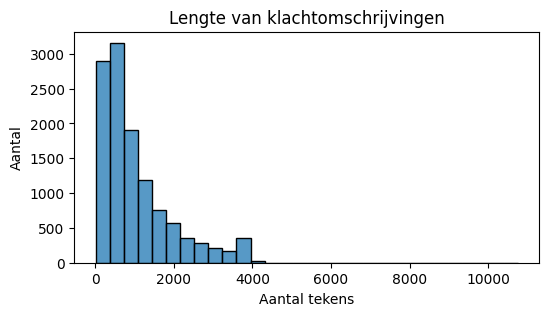

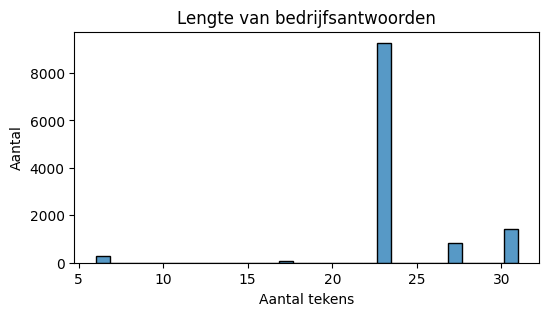

In [29]:
df['Datum_ontvangst'] = pd.to_datetime(df['Datum_ontvangst'], errors='coerce')

# 1. Histogram voor ID
plt.figure(figsize=(6,2))
sns.histplot(df['ID'], bins=30, kde=False)
plt.title("Verdeling van ID's")
plt.xlabel("ID")
plt.ylabel("Aantal")
plt.show()

# 2. Histogram voor Datum_ontvangst (tijdreeks, per maand)
plt.figure(figsize=(6,3))
df['Datum_ontvangst'].dt.to_period("M").value_counts().sort_index().plot(kind="bar")
plt.title("Aantal klachten per maand")
plt.xlabel("Maand")
plt.ylabel("Aantal klachten")
plt.show()

# 3. Bar chart voor Product
plt.figure(figsize=(4,2))
df['Product'].value_counts().plot(kind="bar")
plt.title("Verdeling klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.show()

# 4. Lengte van Omschrijving (hoeveel tekst per klacht)
df['Omschrijving_lengte'] = df['Omschrijving'].str.len()
plt.figure(figsize=(6,3))
sns.histplot(df['Omschrijving_lengte'], bins=30, kde=False)
plt.title("Lengte van klachtomschrijvingen")
plt.xlabel("Aantal tekens")
plt.ylabel("Aantal")
plt.show()

# 5. Lengte van Antwoord_bedrijf (hoe uitgebreid reageren bedrijven)
df['Antwoord_lengte'] = df['Antwoord_bedrijf'].str.len()
plt.figure(figsize=(6,3))
sns.histplot(df['Antwoord_lengte'], bins=30, kde=False)
plt.title("Lengte van bedrijfsantwoorden")
plt.xlabel("Aantal tekens")
plt.ylabel("Aantal")
plt.show()

In [30]:
df.shape
print("De dataset bevat {} rijen en {} kolommen.".format(df.shape[0], df.shape[1]))

De dataset bevat 11909 rijen en 7 kolommen.
